# Digital Payments Transaction Analytics — RFM Segmentation & Volume Forecast

Aggregation is done in DuckDB directly against the CSV (never loads the full 6.3M-row table
into pandas — only small, already-aggregated results), then scored/labeled in pandas.

In [1]:
import duckdb
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "PS_20174392719_1491204439457_log.csv"
OUT = ROOT / "outputs"

con = duckdb.connect()
con.execute(f"CREATE VIEW transactions AS SELECT * FROM read_csv_auto('{DATA}')")
max_step = con.execute("SELECT MAX(step) FROM transactions").fetchone()[0]
max_step

743

## RFM segmentation (per `nameOrig`)

In [2]:
rfm = con.execute("""
    SELECT
        nameOrig,
        MAX(step) AS recency_step,
        COUNT(*) AS frequency,
        SUM(amount) AS monetary
    FROM transactions
    GROUP BY nameOrig
""").fetchdf()

rfm["recency"] = max_step - rfm["recency_step"]
rfm["r_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1], duplicates="drop").astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4], duplicates="drop").astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4], duplicates="drop").astype(int)
# note: duplicates="drop" can collapse a quartile to fewer than 4 buckets on heavily skewed
# columns (frequency/monetary are long-tailed here) -- accepted, not a bug.

len(rfm)

6353307

In [3]:
def label_segment(row):
    if row.f_score >= 3 and row.m_score >= 3:
        return "High-value regulars"
    if row.f_score <= 2 and row.m_score >= 3:
        return "High-value one-off"
    if row.f_score >= 3 and row.m_score <= 2:
        return "Low-value frequent"
    if row.r_score <= 2:
        return "Dormant"
    return "Standard"

rfm["segment"] = rfm.apply(label_segment, axis=1)

segment_summary = (
    rfm.groupby("segment")
    .agg(accounts=("nameOrig", "count"), total_value=("monetary", "sum"))
    .reset_index()
    .sort_values("total_value", ascending=False)
)
segment_summary["pct_of_accounts"] = (100 * segment_summary["accounts"] / segment_summary["accounts"].sum()).round(2)
segment_summary["pct_of_value"] = (100 * segment_summary["total_value"] / segment_summary["total_value"].sum()).round(2)
segment_summary

,segment,accounts,total_value,pct_of_accounts,pct_of_value
2,High-value regulars,1588249,5.407903e+11,25.00,47.26
1,High-value one-off,1588404,5.380524e+11,25.00,47.02
3,Low-value frequent,1588404,3.278325e+10,25.00,2.86
4,Standard,792275,1.693734e+10,12.47,1.48
0,Dormant,795975,1.582964e+10,12.53,1.38


In [4]:
rfm_size_mb = rfm.memory_usage(deep=True).sum() / 1e6
print(f"rfm_segments_detail: {len(rfm):,} rows, ~{rfm_size_mb:.1f} MB in memory")

rfm.to_csv(OUT / "rfm_segments_detail.csv", index=False)
segment_summary.to_csv(OUT / "segment_summary.csv", index=False)

assert abs(segment_summary["pct_of_accounts"].sum() - 100) < 0.1
assert abs(segment_summary["pct_of_value"].sum() - 100) < 0.1
print("sanity check passed: segment percentages sum to 100")

rfm_segments_detail: 6,353,307 rows, ~1144.3 MB in memory


sanity check passed: segment percentages sum to 100


## Daily volume forecast (7-day linear trend)

In [5]:
daily = con.execute("""
    SELECT CEIL(step / 24.0) AS day, COUNT(*) AS txn_count, SUM(amount) AS txn_value
    FROM transactions
    GROUP BY day
    ORDER BY day
""").fetchdf()

recent = daily.tail(7)  # day 1-17 runs 5-14x higher than day 18-31 (level shift);
# a full-history fit's slope overshoots negative on extrapolation, so trend on the recent
# regime instead, and floor at 0 since transaction value can't go negative.
coeffs = np.polyfit(recent["day"], recent["txn_value"], 1)
future_days = np.arange(daily["day"].max() + 1, daily["day"].max() + 8)
forecast_values = np.clip(np.polyval(coeffs, future_days), 0, None)

actual = daily[["day", "txn_value"]].rename(columns={"txn_value": "value"})
actual["type"] = "actual"
forecast = pd.DataFrame({"day": future_days, "value": forecast_values, "type": "forecast"})

combined = pd.concat([actual, forecast], ignore_index=True)
combined.to_csv(OUT / "daily_volume_with_forecast.csv", index=False)
combined.tail(10)

,day,value,type
28,29.0,9.357636e+09,actual
29,30.0,1.995900e+09,actual
30,31.0,4.480862e+08,actual
31,32.0,1.274050e+09,forecast
32,33.0,5.936056e+08,forecast
33,34.0,0.000000e+00,forecast
34,35.0,0.000000e+00,forecast
35,36.0,0.000000e+00,forecast
36,37.0,0.000000e+00,forecast
37,38.0,0.000000e+00,forecast


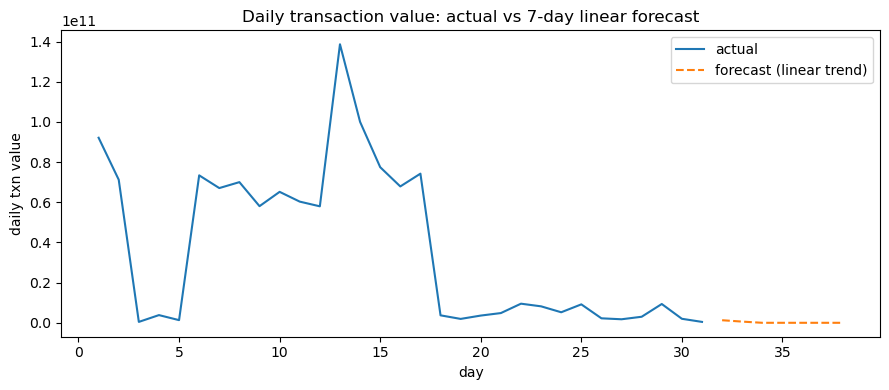

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(actual["day"], actual["value"], label="actual")
ax.plot(forecast["day"], forecast["value"], "--", label="forecast (linear trend)")
ax.set_xlabel("day"); ax.set_ylabel("daily txn value"); ax.legend()
ax.set_title("Daily transaction value: actual vs 7-day linear forecast")
plt.tight_layout()
plt.show()